In [29]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('frc-data.db') 

# Create a cursor object
cursor = conn.cursor()

#team_number = input("What team do you want information on? ")
#team_number = int(team_number)
team_number = 578
#team_number = 27 # Team Rush
#team_number = 1559 # Devil Tech (Victor)
#team_number = 1519 # Greece Gladiators
#team_number = 3181 # Pittsford
#team_number = 20
measure = "Final" # Auto Teleop or Final

In [30]:
cursor.execute(f'''SELECT data.* FROM data
INNER JOIN event ON data.event_code = event.code AND data.year = event.year
WHERE event.type = "Regional"
--AND  data.tournamentLevel = "Qualification"
AND (
	data.Blue1 = {team_number} OR data.Blue2 = {team_number} OR data.Blue3 = {team_number} OR data.Red1 = {team_number} OR data.Red2 = {team_number} OR data.Red3 = {team_number} 
)
ORDER BY event_date, matchNumber''')

names = [description[0] for description in cursor.description]

win_loss_data = {}
for row in cursor.fetchall():
    i = dict(zip(names, row))

    try:
        i["scoreRedTeleop"] = i["scoreRedFinal"] - i["scoreRedAuto"] - i["scoreRedFoul"]
        i["scoreBlueTeleop"] = i["scoreBlueFinal"] - i["scoreBlueAuto"] - i["scoreBlueFoul"] 
    
        if i["scoreBlueTeleop"] == i["scoreRedTeleop"]:
            i["winnerTeleop"] = "Tie"
        elif i["scoreBlueTeleop"] > i["scoreRedTeleop"]:
            i["winnerTeleop"] = "Blue"
        else:
            i["winnerTeleop"] = "Red"
    except:
        i["winnerTeleop"] = "Unknown"
        continue
    

    if i["scoreBlueAuto"] == None or i["scoreRedAuto"] == None:
        i["winnerAuto"] = "Unknown"
    elif i["scoreBlueAuto"] == i["scoreRedAuto"]:
        i["winnerAuto"] = "Tie"
    elif i["scoreBlueAuto"] > i["scoreRedAuto"]:
        i["winnerAuto"] = "Blue"
    else:
        i["winnerAuto"] = "Red"  
    
    
    if i["scoreBlueFinal"] == None or i["scoreRedFinal"] == None:
        i["winnerFinal"] = "Unknown"
    elif i["scoreBlueFinal"] == i["scoreRedFinal"]:
        i["winnerFinal"] = "Tie"
    elif i["scoreBlueFinal"] > i["scoreRedFinal"]:
        i["winnerFinal"] = "Blue"
    else:
        i["winnerFinal"] = "Red"


    if int(i["Blue1"]) == team_number or int(i["Blue2"]) == team_number or int(i["Blue3"]) == team_number:
        i["teamColor"] = "Blue"
    elif int(i["Red1"]) == team_number or int(i["Red2"]) == team_number or int(i["Red3"]) == team_number:
        i["teamColor"] = "Red"
    else:
        i["teamColor"] = "Error"

    win_loss_data_row = win_loss_data.get(i["year"], {})
    
    
    
    if int(i["year"]) >= 2015:
        # Auto
        auto = win_loss_data_row.get("Auto", "")
        dash = "-"
        if len(auto) == 0:
            dash = ""

        if i["winnerAuto"] == "Tie":
            auto = f"{auto}{dash}T"
        elif i["teamColor"] == i["winnerAuto"]:
            auto = f"{auto}{dash}W"
        elif i["winnerAuto"] == "Unknown":
            _ = 1
        else:
            auto = f"{auto}{dash}L"
        win_loss_data_row["Auto"] = auto

        # Teleop
        teleop = win_loss_data_row.get("Teleop", "")
        dash = "-"
        if len(teleop) == 0:
            dash = ""

        if i["winnerTeleop"] == "Tie":
            teleop = f"{teleop}{dash}T"
        elif i["teamColor"] == i["winnerTeleop"]:
            teleop = f"{teleop}{dash}W"
        elif i["winnerTeleop"] == "Unknown":
            _ = 1
        else:
            teleop = f"{teleop}{dash}L"
        win_loss_data_row["Teleop"] = teleop

    
    # Final
    final = win_loss_data_row.get("Final", "")
    dash = "-"
    if len(final) == 0:
        dash = ""

    if i["winnerFinal"] == "Tie":
        final=f"{final}{dash}T"
    elif i["teamColor"] == i["winnerFinal"]:
        final=f"{final}{dash}W"
    elif i["winnerFinal"] == "Unknown":
        _ = 1
    else:
        final=f"{final}{dash}L"
    win_loss_data_row["Final"] = final
    win_loss_data[i["year"]] = win_loss_data_row

    



In [31]:
def beta_mu(wins, losses, priors=0.5):
     # Define parameters
    alpha = wins + priors
    beta = losses + priors
    return alpha / (alpha + beta)

In [32]:
def beta_sd(wins, losses, priors=0.5):
    alpha = wins + priors
    beta = losses + priors
    return pow((alpha * beta) / (pow(alpha + beta, 2) * (alpha + beta + 1)), 0.5)

In [33]:
w = 0
l = 0
mean_1 = []
std_1 = []
years_1 = []
for year in win_loss_data.keys():
#    print(year)
    try:
        for f in  win_loss_data.get(year).get(measure).split("-"):
            if f == "W":
                w += 1
            else:
                l += 1
            mu = beta_mu(w,l)
            sigma = beta_sd(w,l)
            mean_1.append(mu)
            std_1.append(sigma)
            years_1.append(year)
    except:
        continue

# Visualization

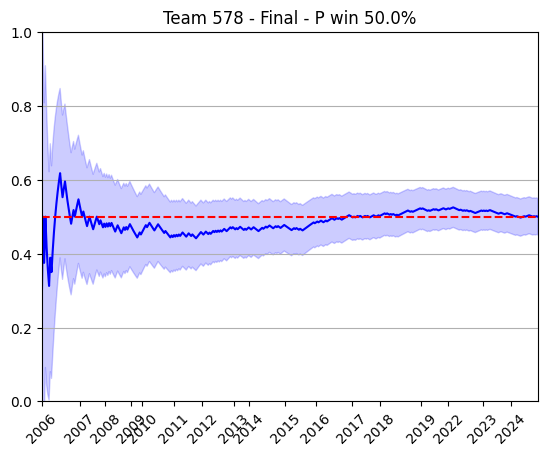

In [34]:
i = 0
current_label = ''
labels = []
labels_x = []
for y in years_1:
    if not y == current_label:
        labels_x.append(i)
        labels.append(y)
        current_label = y
    i += 1

last_mu = round(mean_1[-1], 3) * 100
mean_1 = np.array(mean_1)
std_1 = np.array(std_1)

x = np.arange(len(mean_1))
plt.plot(x, mean_1, 'b-', label='mean_1')
plt.fill_between(x, mean_1 - (2*std_1), mean_1 + (2*std_1), color='b', alpha=0.2)
plt.ylim(0, 1)
plt.xticks(labels_x, labels, rotation=45)
plt.title(f"Team {team_number} - {measure} - P win {last_mu}%")
plt.margins(x=0)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.grid(axis = 'y')

In [37]:
pd.DataFrame( [round(p,3) for p in mean_1[[l-1 for l in labels_x]].tolist()], columns=['P win (Start of Season)'], index = labels)

,P win (Start of Season)
2006,0.500
2007,0.547
2008,0.481
2009,0.480
2010,0.452
2011,0.445
2012,0.458
2013,0.472
2014,0.468
2015,0.477
